In [1]:
import pandas as pd

# ------------------------------------
# 0) Charger les données
# ------------------------------------
df = pd.read_csv("df_business_2025.csv", parse_dates=["SubmissionDate"])

# Colonne année-mois pour l’agrégation
df["YearMonth"] = df["SubmissionDate"].dt.to_period("M").astype(str)

# ------------------------------------
# 1) Nombre de chaque business type par mois
# ------------------------------------
bt_month = (
    df.groupby(["YearMonth", "BusinessTypeName"], as_index=False)
      .size()
      .rename(columns={"size": "n_business"})
)

# Exemple d’aperçu
print("1) Business type par mois")
print(bt_month.head(), "\n")

# ------------------------------------
# 2) Nombre de chaque business type par mois, par département responsable
# ------------------------------------
bt_month_dept = (
    df.groupby(
        ["YearMonth", "ResponsibleDepartmentAbbreviation", "BusinessTypeName"],
        as_index=False,
    )
      .size()
      .rename(columns={"size": "n_business"})
)

print("2) Business type par mois ET département")
print(bt_month_dept.head(), "\n")

# ------------------------------------
# Préparation des TagNames (split + explode)
# ------------------------------------
tags = (
    df[["YearMonth", "ResponsibleDepartmentAbbreviation", "TagNames"]]
    .dropna(subset=["TagNames"])
    .assign(TagName=lambda d: d["TagNames"].str.split("|"))
    .explode("TagName")
)

tags["TagName"] = tags["TagName"].str.strip()
tags = tags[tags["TagName"] != ""]  # enlever les éventuels vides

# ------------------------------------
# 3) Nombre de chaque type de TagNames par mois
# ------------------------------------
tag_month = (
    tags.groupby(["YearMonth", "TagName"], as_index=False)
        .size()
        .rename(columns={"size": "n_tags"})
)

print("3) TagNames par mois")
print(tag_month.head(), "\n")

# ------------------------------------
# 4) Nombre de chaque type de TagNames par mois, par département responsable
# ------------------------------------
tag_month_dept = (
    tags.groupby(
        ["YearMonth", "ResponsibleDepartmentAbbreviation", "TagName"],
        as_index=False,
    )
        .size()
        .rename(columns={"size": "n_tags"})
)

print("4) TagNames par mois ET département")
print(tag_month_dept.head(), "\n")

# ------------------------------------
# (Optionnel) Sauvegarde des tableaux
# ------------------------------------
# bt_month.to_csv("business_type_par_mois.csv", index=False)
# bt_month_dept.to_csv("business_type_par_mois_dep.csv", index=False)
# tag_month.to_csv("tagnames_par_mois.csv", index=False)
# tag_month_dept.to_csv("tagnames_par_mois_dep.csv", index=False)


1) Business type par mois
  YearMonth    BusinessTypeName  n_business
0   2025-01              Motion          15
1   2025-01            Postulat           6
2   2025-02              Motion           5
3   2025-02            Postulat           3
4   2025-03  Fragestunde. Frage         275 

2) Business type par mois ET département
  YearMonth ResponsibleDepartmentAbbreviation BusinessTypeName  n_business
0   2025-01                                BK           Motion           1
1   2025-01                               EDI           Motion           6
2   2025-01                               EDI         Postulat           1
3   2025-01                               EFD         Postulat           1
4   2025-01                              EJPD         Postulat           1 

3) TagNames par mois
  YearMonth                   TagName  n_tags
0   2025-01  Beschäftigung und Arbeit       3
1   2025-01               Finanzwesen       3
2   2025-01                Gesundheit       6
3   2025-0

/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/2985429604.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["SubmissionDate"].dt.to_period("M").astype(str)


/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["SubmissionDate"].dt.to_period("M").astype(str)
/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dept_matrix = pd.DataFrame(index=months, columns=depts).fillna(0)
/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dept = plt.cm.get_cmap("tab20"

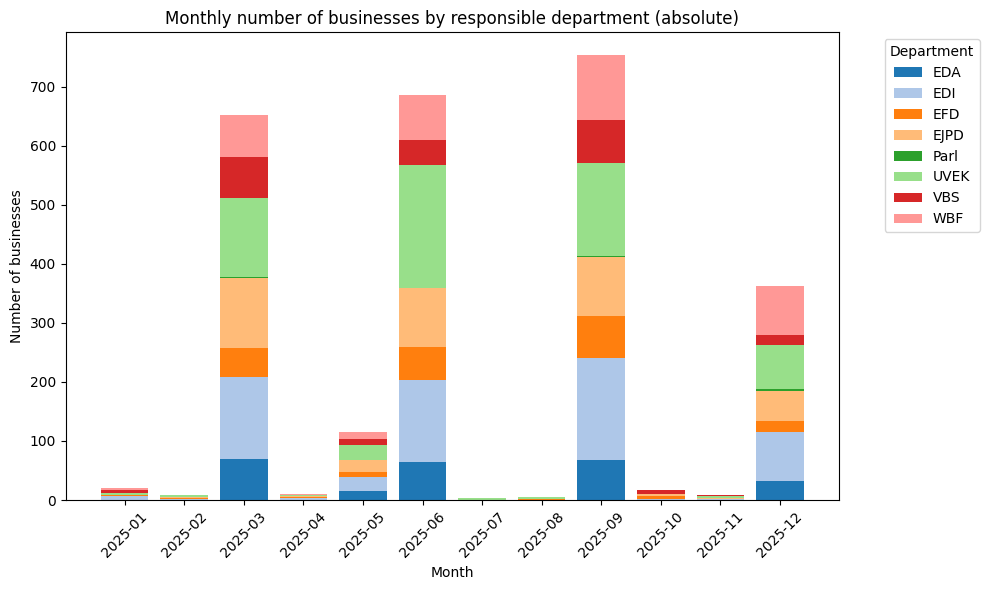

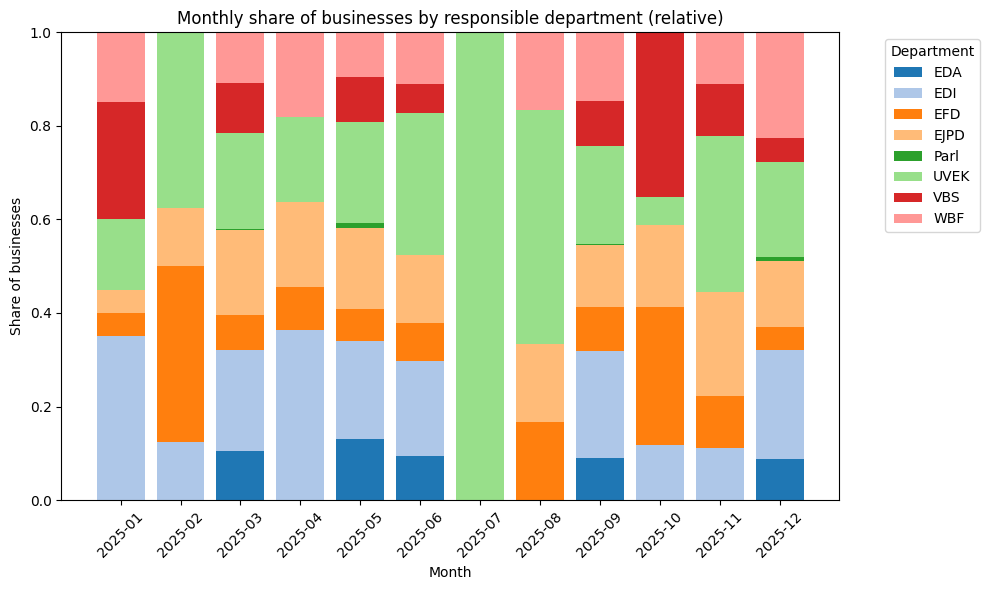

/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tag_matrix = pd.DataFrame(index=months, columns=tag_labels).fillna(0.0)
/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_tag = plt.cm.get_cmap("tab20")


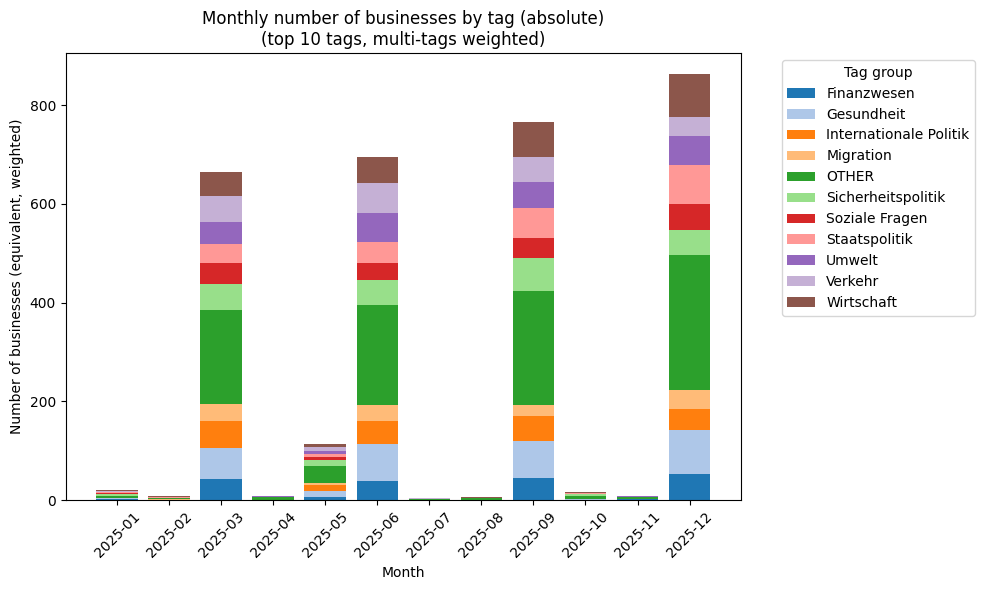

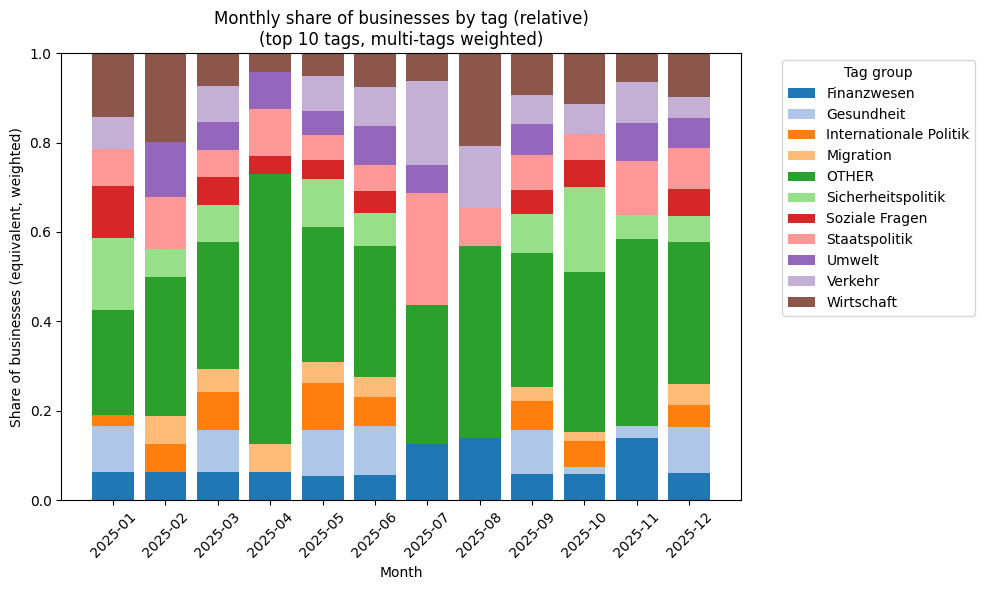

/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:202: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bt_matrix = pd.DataFrame(index=months, columns=bt_names).fillna(0)
/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_3415/1549463500.py:208: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bt = plt.cm.get_cmap("tab10")


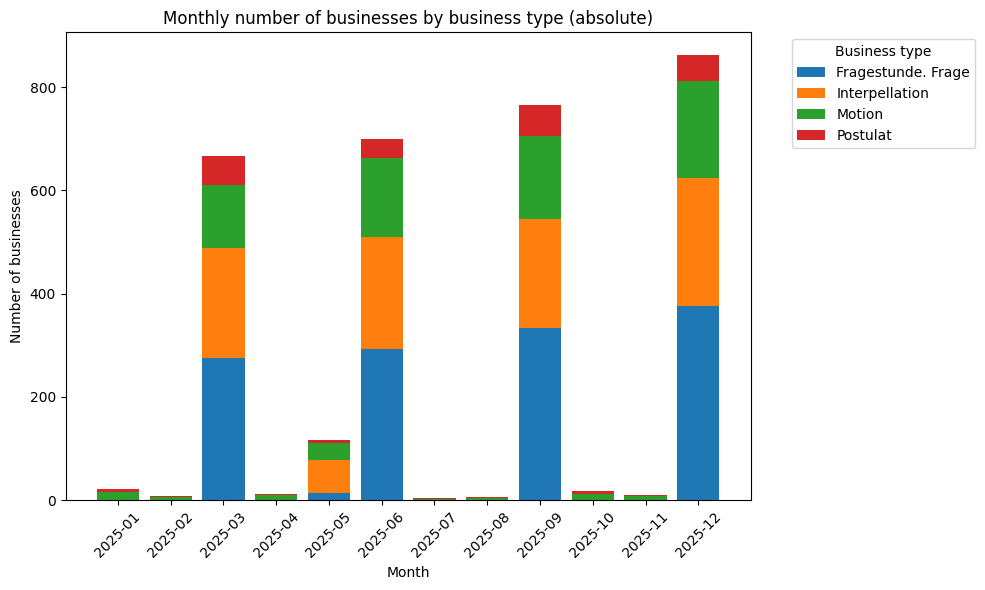

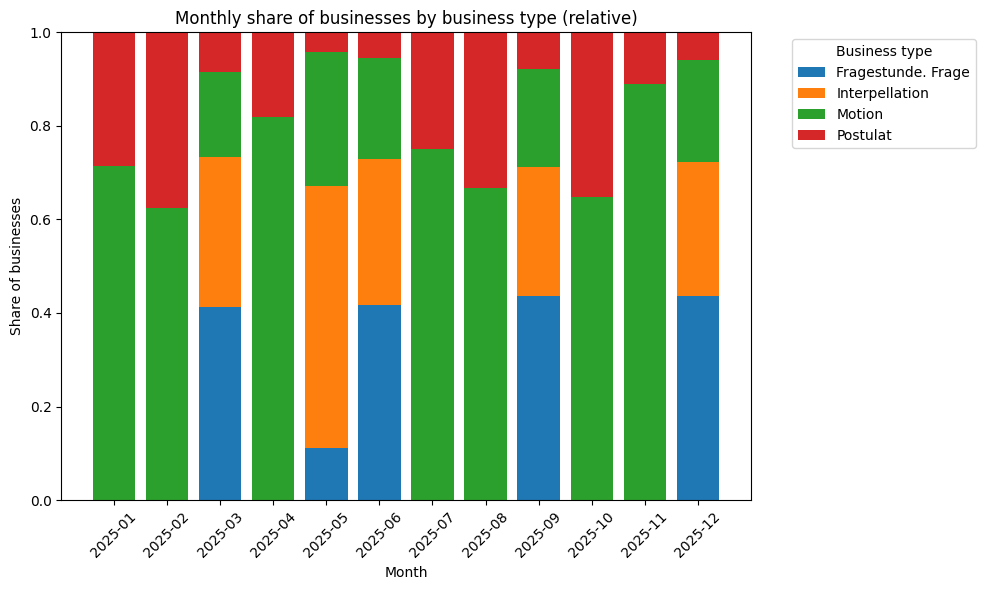

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0) Load data
# ============================================================
df = pd.read_csv("df_business_2025.csv", parse_dates=["SubmissionDate"])

# Year-month column for time axis
df["YearMonth"] = df["SubmissionDate"].dt.to_period("M").astype(str)
months = sorted(df["YearMonth"].unique())

# ============================================================
# 1) STACKED BARS BY RESPONSIBLE DEPARTMENT (ABSOLUTE + RELATIVE)
#    Excluding departments: BGer, BK, Par
# ============================================================
EXCLUDED_DEPTS = {"BGer", "BK", "Par"}

dept_counts = (
    df.groupby(["YearMonth", "ResponsibleDepartmentAbbreviation"])
      .size()
      .reset_index(name="n")
)

# Remove excluded departments and NaNs
dept_counts = dept_counts[
    dept_counts["ResponsibleDepartmentAbbreviation"].notna()
    & ~dept_counts["ResponsibleDepartmentAbbreviation"].isin(EXCLUDED_DEPTS)
]

depts = sorted(dept_counts["ResponsibleDepartmentAbbreviation"].unique())

# Build matrix (months x departments)
dept_matrix = pd.DataFrame(index=months, columns=depts).fillna(0)

for _, row in dept_counts.iterrows():
    dept_matrix.loc[row["YearMonth"], row["ResponsibleDepartmentAbbreviation"]] = row["n"]

# Color map per department (stable across plots)
cmap_dept = plt.cm.get_cmap("tab20")
colors_dept = {dept: cmap_dept(i % 20) for i, dept in enumerate(depts)}

# ---------- 1A) Absolute stacked bar chart ----------
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for dept in depts:
    values = dept_matrix[dept].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=dept, color=colors_dept[dept])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Number of businesses")
ax.set_title("Monthly number of businesses by responsible department (absolute)")
ax.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- 1B) Relative (share) stacked bar chart ----------
dept_share_matrix = (
    dept_matrix.div(dept_matrix.sum(axis=1).replace(0, np.nan), axis=0)
              .fillna(0.0)
)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for dept in depts:
    values = dept_share_matrix[dept].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=dept, color=colors_dept[dept])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Share of businesses")
ax.set_title("Monthly share of businesses by responsible department (relative)")
ax.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ============================================================
# 2) STACKED BARS BY TAG (ABSOLUTE + RELATIVE)
#    Multi-tags: each business has weight 1 split across its tags
# ============================================================
tags = (
    df[["ID", "YearMonth", "TagNames"]]
      .dropna(subset=["TagNames"])
      .copy()
)

tags["TagName"] = tags["TagNames"].str.split("|")
tags = tags.explode("TagName")
tags["TagName"] = tags["TagName"].str.strip()
tags = tags[tags["TagName"] != ""]

# Number of tags per (YearMonth, ID) to define weights
tags["n_tags_for_business"] = (
    tags.groupby(["YearMonth", "ID"])["TagName"].transform("count")
)
tags["weight"] = 1.0 / tags["n_tags_for_business"]

tag_month = (
    tags.groupby(["YearMonth", "TagName"])["weight"]
        .sum()
        .reset_index(name="n_business_equiv")
)

# To keep the plot readable: restrict to top N tags, group the rest as "OTHER"
N_TOP_TAGS = 10
top_tags = (
    tag_month.groupby("TagName")["n_business_equiv"]
             .sum()
             .sort_values(ascending=False)
             .head(N_TOP_TAGS)
             .index.tolist()
)

tag_month["TagGroup"] = np.where(
    tag_month["TagName"].isin(top_tags),
    tag_month["TagName"],
    "OTHER"
)

tag_grouped = (
    tag_month.groupby(["YearMonth", "TagGroup"])["n_business_equiv"]
             .sum()
             .reset_index()
)

tag_labels = sorted(tag_grouped["TagGroup"].unique())

# Matrix (months x TagGroup)
tag_matrix = pd.DataFrame(index=months, columns=tag_labels).fillna(0.0)

for _, row in tag_grouped.iterrows():
    tag_matrix.loc[row["YearMonth"], row["TagGroup"]] = row["n_business_equiv"]

# Color map per TagGroup (stable)
cmap_tag = plt.cm.get_cmap("tab20")
colors_tag = {tag: cmap_tag(i % 20) for i, tag in enumerate(tag_labels)}

# ---------- 2A) Absolute stacked bar chart ----------
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for tag in tag_labels:
    values = tag_matrix[tag].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=tag, color=colors_tag[tag])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Number of businesses (equivalent, weighted)")
ax.set_title(
    f"Monthly number of businesses by tag (absolute)\n"
    f"(top {N_TOP_TAGS} tags, multi-tags weighted)"
)
ax.legend(title="Tag group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- 2B) Relative (share) stacked bar chart ----------
tag_share_matrix = (
    tag_matrix.div(tag_matrix.sum(axis=1).replace(0, np.nan), axis=0)
              .fillna(0.0)
)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for tag in tag_labels:
    values = tag_share_matrix[tag].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=tag, color=colors_tag[tag])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Share of businesses (equivalent, weighted)")
ax.set_title(
    f"Monthly share of businesses by tag (relative)\n"
    f"(top {N_TOP_TAGS} tags, multi-tags weighted)"
)
ax.legend(title="Tag group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ============================================================
# 3) STACKED BARS BY BUSINESS TYPE (ABSOLUTE + RELATIVE)
# ============================================================
bt_counts = (
    df.groupby(["YearMonth", "BusinessTypeName"])
      .size()
      .reset_index(name="n")
)

bt_names = sorted(bt_counts["BusinessTypeName"].dropna().unique())

bt_matrix = pd.DataFrame(index=months, columns=bt_names).fillna(0)

for _, row in bt_counts.iterrows():
    bt_matrix.loc[row["YearMonth"], row["BusinessTypeName"]] = row["n"]

# Color map per BusinessTypeName (stable)
cmap_bt = plt.cm.get_cmap("tab10")
colors_bt = {bt: cmap_bt(i % 10) for i, bt in enumerate(bt_names)}

# ---------- 3A) Absolute stacked bar chart ----------
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for bt in bt_names:
    values = bt_matrix[bt].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=bt, color=colors_bt[bt])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Number of businesses")
ax.set_title("Monthly number of businesses by business type (absolute)")
ax.legend(title="Business type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- 3B) Relative (share) stacked bar chart ----------
bt_share_matrix = (
    bt_matrix.div(bt_matrix.sum(axis=1).replace(0, np.nan), axis=0)
             .fillna(0.0)
)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(months))

for bt in bt_names:
    values = bt_share_matrix[bt].values.astype(float)
    ax.bar(months, values, bottom=bottom, label=bt, color=colors_bt[bt])
    bottom += values

ax.set_xlabel("Month")
ax.set_ylabel("Share of businesses")
ax.set_title("Monthly share of businesses by business type (relative)")
ax.legend(title="Business type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
